In [1]:
import numpy as np
import os
from functools import partial
from scipy.linalg import cholesky

# -------------------------------
# Helper: Check Positive Definiteness
# -------------------------------
def is_positive_definite(x):
    return np.all(np.linalg.eigvals(x) > 0)

# -------------------------------
# Kernel and Covariance Functions
# -------------------------------
def kernel(h1, h2, l, nu):
    # 1 <= nu <= 2, l is bandwidth
    return np.exp(-np.abs(h1 - h2)**nu / (2 * l))

def sigma_matrix_gen(image_size, seed=66):
    np.random.seed(seed)
    # Control the variance of the random matrix.
    sigma = 1
    random_matrix = np.random.randn(image_size, image_size) * (sigma)
    sigma_matrix = np.dot(random_matrix, random_matrix.T)
    # Optionally scale the matrix; here we just check PD status.
    print("Sigma matrix:\n", sigma_matrix)
    print("Is sigma matrix PD?", is_positive_definite(sigma_matrix))
    return sigma_matrix

def kernel_matrix_gen(seq_length, l, nu, seed=66):
    np.random.seed(seed)
    partial_kernel = partial(kernel, l=l, nu=nu)
    # Use np.fromfunction with vectorization; add a tiny diagonal for stability.
    kernel_matrix = np.fromfunction(np.vectorize(partial_kernel), (seq_length, seq_length)) + np.eye(seq_length) * 1e-6
    print("Is kernel matrix PD?", is_positive_definite(kernel_matrix))
    return kernel_matrix

# -------------------------------
# GP Data Generation Using Cholesky
# -------------------------------
def generate_latent_gp_data(num, l, nu, image_size, seq_length, seed=66, latent=True):
    # Generate spatial and temporal covariances.
    sigma_matrix = sigma_matrix_gen(image_size)
    kernel_matrix = kernel_matrix_gen(seq_length, l, nu)
    # Construct full covariance via Kronecker product.
    cov = np.kron(kernel_matrix, sigma_matrix)
    mean = np.zeros(cov.shape[0])
    
    # Precompute the lower-triangular Cholesky factor.
    l_matrix = cholesky(cov, lower=True)
    
    data_list = []
    data_latent_list = []
    np.random.seed(seed)
    for _ in range(num):
        z = np.random.standard_normal(len(mean))
        if latent:
            sample_latent = mean + l_matrix @ z  # Transform standard normal via Cholesky.
            # reshape to match the original data shape.
            sample_latent = sample_latent.reshape((seq_length, image_size))
            data_latent_list.append(sample_latent)
            # Assign a transform funtion to the data pointwise: y = x + exp(-x^2) + sin(x) + N(0, 0.1)
            sample = sample_latent + np.exp(-sample_latent**2) +  2*  np.sin(sample_latent) + np.random.normal(0, 0.1, sample_latent.shape)
        else:
            sample = mean + l_matrix @ z  # Transform standard normal via Cholesky.
        data_list.append(sample.reshape((seq_length, image_size)))
    
    # Save kernel and sigma matrices for reference.
    # os.makedirs("dataset/latent_gp_data", exist_ok=True)
    # np.save('dataset/latent_gp_data/kernel_matrix', kernel_matrix)
    # np.save('dataset/latent_gp_data/sigma_matrix', sigma_matrix)
    
    return np.array(data_latent_list), np.array(data_list), sigma_matrix, kernel_matrix  # Convert list to array for easier indexing

In [2]:
_, data_list, sigma_matrix, kernel_matrix = generate_latent_gp_data(num=2048, l=4, nu=0.8, image_size=1, seq_length=32, latent=False)

Sigma matrix:
 [[2.00396403]]
Is sigma matrix PD? True
Is kernel matrix PD? True


In [3]:
true_cov_matrix = np.kron(kernel_matrix, sigma_matrix)

In [4]:
gen_data = data_list.squeeze(-1)

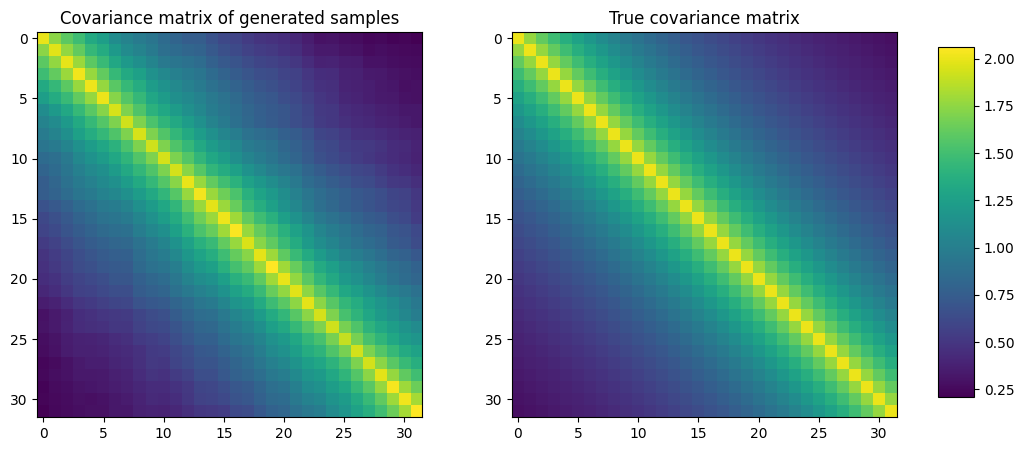

In [5]:
import matplotlib.pyplot as plt

# 1. Compute Empirical Covariance from your samples
# Rowvar=False assumes rows are observations, columns are variables
emp_cov_matrix = np.cov(gen_data, rowvar=False)

# 2. Setup the Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Determine min/max for colorbar scaling so both plots use the same scale
vmin = emp_cov_matrix.min()
vmax = emp_cov_matrix.max()

# 3. Plot Empirical Covariance (Left)
im1 = axes[0].imshow(emp_cov_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Covariance matrix of generated samples')

# 4. Plot True Covariance (Right)
im2 = axes[1].imshow(true_cov_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('True covariance matrix')

# 5. Add a shared Colorbar
# adjustment to place colorbar nicely on the right
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [left, bottom, width, height]
fig.colorbar(im2, cax=cbar_ax)

plt.show()

In [86]:
# save data
os.makedirs("data/latent_gp_data", exist_ok=True)
np.save('data/latent_gp_data/latent_gp_data_len32_ell4_nu0.8', gen_data)

In [6]:
import glob
import os
# Folder path
folder = "/home/yinbinha/adapted_diffusion_model/samples/dfm_latent_gp_data_len32_ell4_nu0.8_ts1765778007_seed42"

# Get all batch files sorted by batch number
files = sorted(glob.glob(os.path.join(folder, "sample_batch*.npy")))

# Load and combine
arrays = []
for f in files:
    arr = np.load(f)
    if arr.shape[1] != 32:
        raise ValueError(f"File {f} has unexpected shape {arr.shape}")
    arrays.append(arr)
    
dit = np.concatenate(arrays, axis=0)

In [7]:
gen_data = np.load('/home/yinbinha/adapted_diffusion_model/data/latent_gp_data/latent_gp_data_len32_ell4_nu0.8.npy')

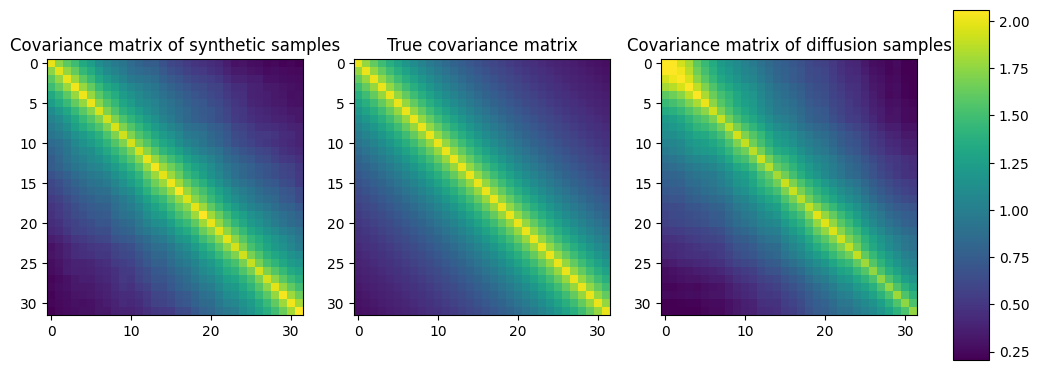

In [13]:
import matplotlib.pyplot as plt


# 1. Compute Empirical Covariance from your samples
# Rowvar=False assumes rows are observations, columns are variables
emp_cov_matrix = np.cov(gen_data, rowvar=False)
# gen_cov_matrix = np.cov(dit, rowvar=False)
gen_cov_matrix = np.cov(dit, rowvar=False)

# 2. Setup the Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Determine min/max for colorbar scaling so both plots use the same scale
vmin = emp_cov_matrix.min()
vmax = emp_cov_matrix.max()

# 3. Plot Empirical Covariance (Left)
im1 = axes[0].imshow(emp_cov_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Covariance matrix of synthetic samples')

# 4. Plot True Covariance (Right)
im2 = axes[1].imshow(true_cov_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('True covariance matrix')

# 3. Plot Empirical Covariance (Left)
im1 = axes[2].imshow(gen_cov_matrix, cmap='viridis', vmin=vmin, vmax=vmax)
axes[2].set_title('Covariance matrix of diffusion samples')

# 5. Add a shared Colorbar
# adjustment to place colorbar nicely on the right
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [left, bottom, width, height]
fig.colorbar(im2, cax=cbar_ax)

plt.savefig('figs/GP_32.png', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
np.linalg.norm(emp_cov_matrix - true_cov_matrix) / np.linalg.norm(true_cov_matrix)

0.04964861321297524

In [10]:
np.linalg.norm(gen_cov_matrix - emp_cov_matrix) / np.linalg.norm(emp_cov_matrix)

0.08278630348369322